# SemEval-2026 Task 13: Detecting Machine-Generated Code with Multiple Programming Languages, Generators, and Application Scenarios
Sitios de interes:
- github.com/mbzuai-nlp/SemEval-2026-Task13

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from typing import Optional
from IPython.display import HTML, display

from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.formatters import HtmlFormatter
from pygments.util import ClassNotFound


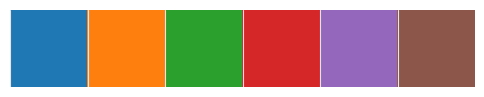

In [215]:
def apply_presentation_theme(font_family='DejaVu Sans', base_size=15, palette=None, grid=True, dpi=100):
    """
    Aplica un tema pensado para presentaciones:
      - base_size: tamaño de fuente base (ajusta todos los demás tamaños)
      - palette: lista de colores hex o nombre de paleta seaborn
      - grid: si True usa grid sutil
      - dpi: resolución de las figuras
    """
    if palette is None:
        # colores contrastantes y claros sobre fondo blanco
        palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    sns.set_theme(style="whitegrid" if grid else "white")
    sns.set_palette(palette)

    rc = {
        "figure.dpi": dpi,
        #figsize
        "figure.figsize": (10, 8),
        "savefig.dpi": dpi,
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": "#222222",
        "axes.linewidth": 1.0,
        "axes.titlesize": int(base_size * 1.4),
        "axes.titleweight": "bold",
        "axes.labelsize": int(base_size * 1.15),
        "xtick.labelsize": int(base_size * 1.0),
        "ytick.labelsize": int(base_size * 1.0),
        "legend.fontsize": int(base_size * 0.95),
        "legend.title_fontsize": int(base_size * 1.0),
        "font.size": base_size,
        "font.family": font_family,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.8,
        "lines.linewidth": 2,
        "lines.markersize": 8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
        #spines
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
    }

    plt.rcParams.update(rc)
def show_presentation_palette(palette=None):
    """
    Dibuja una barra con los colores de la paleta activa o la especificada.
    """
    if palette is None:
        pal = sns.color_palette()
    else:
        pal = sns.color_palette(palette)
    sns.palplot(pal)
    plt.gca().set_frame_on(False)
    plt.show()

def format_ticks_values(formato='k',vertical=False,ax=None):
    """
    Pasa variables continuas a formato K, M, G, etc."""
    from matplotlib.ticker import FuncFormatter

    def k_formatter(x, pos):
        if x >= 1_000_000_000:
            return f'{x / 1_000_000_000:.1f}G'
        elif x >= 1_000_000:
            return f'{x / 1_000_000:.1f}M'
        elif x >= 1_000:
            return f'{x / 1_000:.1f}K'
        else:
            return f'{x:.0f}'
    formatter = FuncFormatter(k_formatter)
    if vertical:
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)

# Requiere: pip install pygments
from typing import Optional
from IPython.display import HTML, display
from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.formatters import HtmlFormatter
from pygments.util import ClassNotFound

def render_code_block(
    code: str,
    language: Optional[str] = None,
    *,
    title: Optional[str] = None,
    style: str = "monokai",
    linenos: bool = True,
    max_height: int = 460,
    font_size_px: int = 14,
    border_radius_px: int = 12,
):
    # Resolver lexer
    try:
        lexer = get_lexer_by_name(language) if language else guess_lexer(code)
    except ClassNotFound:
        lexer = get_lexer_by_name("python")

    fmt = HtmlFormatter(style=style, linenos=linenos)
    highlighted = highlight(code, lexer, fmt)
    css = fmt.get_style_defs('.highlight')

    html = f"""
    <style>
      {css}

      /* --- FIX: forzar LTR y alineación izquierda para evitar "al revés" --- */
      .codecard, .codecard * {{
        direction: ltr !important;
      }}
      .highlight, .highlight pre, .highlight code {{
        direction: ltr !important;
        unicode-bidi: embed;      /* evita reorden bi-di por números/símbolos */
        text-align: left !important;
        white-space: pre;         /* conserva espacios/indentaciones */
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, "Liberation Mono", "DejaVu Sans Mono", monospace;
      }}
      /* -------------------------------------------------------------------- */

      .codecard {{
        border: 1px solid #e5e7eb;
        border-radius: {border_radius_px}px;
        overflow: hidden;
        box-shadow: 0 1px 2px rgba(0,0,0,.04);
        margin: 10px 0 18px 0;
      }}
      .codecard-header {{
        background: #f8fafc;
        padding: 10px 12px;
        display: flex; justify-content: space-between; align-items: center;
        border-bottom: 1px solid #e5e7eb;
        font-family: system-ui, -apple-system, Segoe UI, Roboto, sans-serif;
        font-size: 13px; color: #374151;
      }}
      .codecard-title {{ font-weight: 600; }}
      .codecard-actions button {{
        font-size: 12px; padding: 6px 10px; border-radius: 8px;
        border: 1px solid #d1d5db; background: white; cursor: pointer;
      }}
      .codecard-body {{
        max-height: {max_height}px; overflow: auto;
        font-size: {font_size_px}px;
      }}
      .highlight pre {{ margin: 0; }}
      .highlight {{ background: #272822; }}  /* cambia a 'default' si prefieres tema claro */
    </style>

    <div class="codecard">
      <div class="codecard-header">
        <div class="codecard-title">{title or "Código"}</div>
        <div class="codecard-actions">
          <button onclick="navigator.clipboard.writeText(this.closest('.codecard').querySelector('pre').innerText)">
            Copiar
          </button>
        </div>
      </div>
      <div class="codecard-body">{highlighted}</div>
    </div>
    """
    display(HTML(html))

apply_presentation_theme()

show_presentation_palette()


### Subtask A: Binary Machine-Generated Code Detection

**Goal:**  
Given a code snippet, predict whether it is:

- **(i)** Fully **human-written**, or  
- **(ii)** Fully **machine-generated**

**Training Languages:** `C++`, `Python`, `Java`  
**Training Domain:** `Algorithmic` (e.g., Leetcode-style problems)

**Evaluation Settings:**

| Setting                              | Language                | Domain                 |
|--------------------------------------|-------------------------|------------------------|
| (i) Seen Languages & Seen Domains    | C++, Python, Java       | Algorithmic            |
| (ii) Unseen Languages & Seen Domains | Go, PHP, C#, C, JS      | Algorithmic            |
| (iii) Seen Languages & Unseen Domains| C++, Python, Java       | Research, Production   |
| (iv) Unseen Languages & Domains      | Go, PHP, C#, C, JS      | Research, Production   |


In [216]:
GEN_VERBOSE = {
    "human": "Humano",

    # Qwen
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen 2.5 Coder 1.5B",
    "Qwen/Qwen2.5-Coder-7B-Instruct": "Qwen 2.5 Coder 7B Instruct",
    "Qwen/Qwen2.5-Coder-7B": "Qwen 2.5 Coder 7B",
    "Qwen/Qwen2.5-Coder-32B-Instruct": "Qwen 2.5 Coder 32B Instruct",
    "Qwen/Qwen2.5-Coder-1.5B-Instruct": "Qwen 2.5 Coder 1.5B Instruct",

    # Phi (Microsoft)
    "microsoft/phi-2": "Phi-2",
    "microsoft/Phi-3-medium-4k-instruct": "Phi-3 Medium 4K Instruct",
    "microsoft/Phi-3.5-mini-instruct": "Phi-3.5 Mini Instruct",
    "microsoft/Phi-3-mini-4k-instruct": "Phi-3 Mini 4K Instruct",
    "microsoft/Phi-3-small-8k-instruct": "Phi-3 Small 8K Instruct",

    # CodeLlama
    "codellama/CodeLlama-70b-Instruct-hf": "CodeLlama 70B Instruct",
    "codellama/CodeLlama-34b-Instruct-hf": "CodeLlama 34B Instruct",
    "codellama/CodeLlama-7b-hf": "CodeLlama 7B",

    # Yi Coder (01-ai)
    "01-ai/Yi-Coder-9B": "Yi Coder 9B",
    "01-ai/Yi-Coder-1.5B": "Yi Coder 1.5B",
    "01-ai/Yi-Coder-1.5B-Chat": "Yi Coder 1.5B Chat",
    "01-ai/Yi-Coder-9B-Chat": "Yi Coder 9B Chat",

    # CodeGemma (Google)
    "google/codegemma-7b": "CodeGemma 7B",
    "google/codegemma-2b": "CodeGemma 2B",

    # IBM Granite
    "ibm-granite/granite-8b-code-base-4k": "Granite 8B Code Base 4K",
    "ibm-granite/granite-8b-code-instruct-4k": "Granite 8B Code Instruct 4K",

    # Llama (Meta)
    "meta-llama/Llama-3.2-1B": "Llama 3.2 1B",
    "meta-llama/Llama-3.2-3B": "Llama 3.2 3B",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama 3.1 8B Instruct",
    "meta-llama/Llama-3.1-8B": "Llama 3.1 8B",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama 3.3 70B Instruct",

    # StarCoder (BigCode)
    "bigcode/starcoder": "StarCoder",
    "bigcode/starcoder2-15b": "StarCoder2 15B",
    "bigcode/starcoder2-7b": "StarCoder2 7B",
    "bigcode/starcoder2-3b": "StarCoder2 3B",

    # DeepSeek Coder
    "deepseek-ai/deepseek-coder-1.3b-base": "DeepSeek Coder 1.3B Base",
    "deepseek-ai/deepseek-coder-1.3b-instruct": "DeepSeek Coder 1.3B Instruct",
    "deepseek-ai/deepseek-coder-6.7b-base": "DeepSeek Coder 6.7B Base",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek Coder 6.7B Instruct",
}

In [217]:
def mini_report_task_a(df: pd.DataFrame):
    fig,ax = plt.subplots(2,2, figsize=(12,10))
    sns.countplot(data=df, x='Etiqueta', order=['Humano', 'Generado por IA'], ax=ax[0,0])
    ax[0,0].set_title("Distribución de Etiquetas")
    for p in ax[0,0].patches:
        height = p.get_height()
        ax[0,0].annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',color='#111111', xytext=(0, 5),
                    textcoords='offset points')
    ax[0,0].set_ylabel("Cantidad de muestras")
    format_ticks_values(formato='k', vertical=True, ax=ax[0,0])
    sns.countplot(data=df, x='Lenguaje', ax=ax[0,1])
    ax[0,1].set_title("Distribución de Lenguajes")
    for p in ax[0,1].patches:
        height = p.get_height()
        ax[0,1].annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',color='#111111', xytext=(0, 5),
                    textcoords='offset points')
    format_ticks_values(formato='k', vertical=True, ax=ax[0,1])

    # --- Panel Generadores (eje grande en toda la fila 2) ---
    df_ = df.copy()
    df_['Generador'] = df_['Generador'].str.slice(0, 10) + '...'

    # 1) elimina ambos ejes de la fila inferior
    fig.delaxes(ax[1, 0])
    fig.delaxes(ax[1, 1])

    # 2) reutiliza el gridspec y crea un único eje que abarque la fila inferior
    gs = ax[0, 0].get_gridspec()
    ax_big = fig.add_subplot(gs[1, :])  # ocupa la segunda fila, ambas columnas

    sns.countplot(data=df_, y='Generador',
                  order=df_['Generador'].value_counts().index, ax=ax_big)
    ax_big.set_title("Distribución de Generadores")
    for p in ax_big.patches:
        w = p.get_width()
        ax_big.annotate(f'{int(w):,}', (w, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', color='#111111', xytext=(5, 0),
                        textcoords='offset points')
    format_ticks_values(formato='k', vertical=False, ax=ax_big)

    # (opcional) si necesitas devolver ax como matriz, actualiza referencias
    ax[1, 0] = ax_big
    ax[1, 1] = ax_big
    # renombrar x
    ax_big.set_xlabel("Cantidad de muestras")
    return fig, ax

In [218]:
df_task_a_training = pd.read_parquet("./archive/SemEval-2026-Task13/task_a/task_a_training_set_1.parquet")
df_task_a_training.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_task_a_training['generador_raw'] = df_task_a_training['Generador']
df_task_a_training['Generador'] = df_task_a_training['Generador'].map(GEN_VERBOSE)
df_task_a_training['Etiqueta'] = df_task_a_training['Etiqueta'].map({0: 'Humano', 1: 'Generado por IA'})

In [219]:
df_task_a_training.head()

,Codigo,Generador,Etiqueta,Lenguaje,generador_raw
0,"(a, b, c, d) = [int(x) for x in input().split(...",Humano,Humano,Python,human
1,valid version for the language; all others can...,Qwen 2.5 Coder 1.5B,Generado por IA,Python,Qwen/Qwen2.5-Coder-1.5B
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen 2.5 Coder 7B Instruct,Generado por IA,Python,Qwen/Qwen2.5-Coder-7B-Instruct
3,T = int(input())\nfor t in range(T):\n\tcolor ...,Humano,Humano,Python,human
4,for i in range(int(input())):\n\tinput()\n\ta ...,Humano,Humano,Python,human


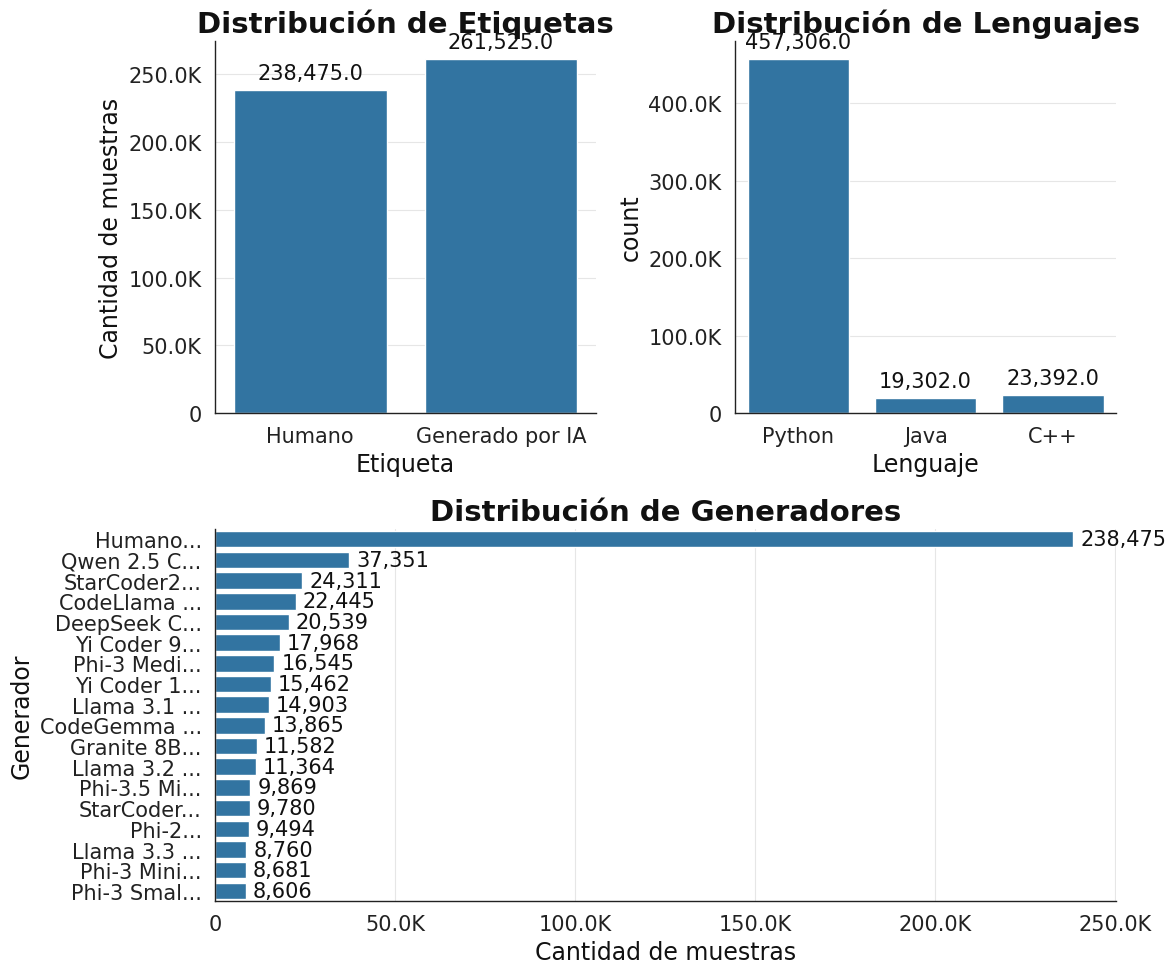

In [220]:
mini_report_task_a(df_task_a_training)
plt.tight_layout()
plt.show()

In [221]:
code = df_task_a_training.iloc[0]['Codigo']
render_code_block(code, language='python', title='Humano')

1 2 3 4 5 6 7 8 9 10 11 12 13,"(a, b, c, d) = [int(x) for x in input().split()] k = input() (p, q, r, s) = (0, 0, 0, 0) for i in k: if i == '1': p += 1 elif i == '2': q += 1 elif i == '3': r += 1 elif i == '4': s += 1 print(a * p + b * q + c * r + d * s)"


In [222]:
code = df_task_a_training.iloc[1]['Codigo']
render_code_block(code, language='python', title='Generado por IA', font_size_px=22)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50


In [223]:
code = df_task_a_training.iloc[2]['Codigo']
render_code_block(code, language='python', title='Generado por IA', font_size_px=22,max_height=560)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21,"python def min_cards_to_flip(s): vowels = {'a', 'e', 'i', 'o', 'u'} odd_digits = {'1', '3', '5', '7', '9'} # Collect all cards with vowels and all cards with odd digits cards_with_vowels = [i for i, char in enumerate(s) if char in vowels] cards_with_odd_digits = [i for i, char in enumerate(s) if char in odd_digits] # Calculate the minimum number of cards to flip if not cards_with_vowels: return 0 cards_to_flip = set(cards_with_vowels) | set(cards_with_odd_digits) return len(cards_to_flip) # Example usage: print(min_cards_to_flip(""ee"")) # Output: 2 print(min_cards_to_flip(""z"")) # Output: 0 print(min_cards_to_flip(""0ay1"")) # Output: 2"
